In [27]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('Cleaned/finaldataset.csv')

In [29]:
df = df.drop(['date', 'FEDRates'], axis=1)

In [30]:
# Convert numerical columns to categorical (High, Medium, Low)
def categorize_column(column):
    q1 = column.quantile(0.33)
    q2 = column.quantile(0.66)
    return column.apply(lambda x: 'Low' if x <= q1 else ('Medium' if x <= q2 else 'High'))

In [31]:
df_categorized = df.copy()
for col in df.columns:
    df_categorized[col] = categorize_column(df[col])

In [32]:
# Save prepared transaction-like data for transparency
df_categorized.to_csv('Cleaned/ARM_prepared_data.csv', index=False)

In [33]:
df_categorized.head()

,ConsumerPriceIndexAllItems,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,Low,Low,Low,Medium,Low,Low,Low,Medium
1,Low,Low,Low,Medium,Low,Low,Low,Medium
2,Low,Low,Low,Medium,Low,Low,Low,Medium
3,Low,Low,Low,Medium,Low,Low,Low,Medium
4,Low,Low,Low,Medium,Low,Low,Low,Medium


In [34]:
# One-hot encoding for ARM
df_encoded = pd.get_dummies(df_categorized)

In [35]:
# Run Apriori to find frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

In [36]:
# Derive association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

In [14]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

In [37]:
# Save rules for transparency
rules.to_csv('Cleaned/association_rules.csv', index=False)

In [39]:
rules.sort_values('lift', ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
18246,"(RealGDPPerCapita_Low, RealGDP_Low, InflationC...","(ConsumerPriceIndexAllItems_High, GDP_Low, Rea...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
18245,"(RealGDPPerCapita_Low, InflationConsumerPrice_...","(ConsumerPriceIndexAllItems_High, RealGDP_Low,...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
18972,"(RealGDPPerCapita_Low, MedianConsumerPriceInde...","(ConsumerPriceIndexAllItems_High, RealGDP_Low)",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
18247,"(RealGDPPerCapita_Low, InflationConsumerPrice_...","(ConsumerPriceIndexAllItems_High, RealGDP_Low,...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
18973,"(RealGDPPerCapita_Low, RealGDP_Low, MedianCons...","(ConsumerPriceIndexAllItems_High, RealPotentia...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
9137,"(RealGDPPerCapita_Low, InflationConsumerPrice_...","(ConsumerPriceIndexAllItems_High, GDP_Low)",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
24771,"(RealGDPPerCapita_Low, RealGDP_Low, InflationC...","(ConsumerPriceIndexAllItems_High, MedianConsum...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
24770,"(RealGDPPerCapita_Low, InflationConsumerPrice_...","(ConsumerPriceIndexAllItems_High, RealGDP_Low,...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
24772,"(RealGDPPerCapita_Low, InflationConsumerPrice_...","(ConsumerPriceIndexAllItems_High, RealGDP_Low,...",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862
18230,"(RealGDPPerCapita_Low, RealGDP_Low, InflationC...","(ConsumerPriceIndexAllItems_High, GDP_Low)",0.120567,0.095745,0.076832,0.637255,6.655773,1.0,0.065288,2.492812,0.966253,0.550847,0.598847,0.719862


In [41]:
rules.sort_values('support', ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
82,(GDP_High),(RealPotentialGDP_High),0.340426,0.340426,0.340426,1.000000,2.937500,1.0,0.224536,inf,1.000000,1.000000,1.000000,1.000000
83,(RealPotentialGDP_High),(GDP_High),0.340426,0.340426,0.340426,1.000000,2.937500,1.0,0.224536,inf,1.000000,1.000000,1.000000,1.000000
78,(GDP_High),(RealGDP_High),0.340426,0.340426,0.336879,0.989583,2.906901,1.0,0.220990,63.319149,0.994567,0.979381,0.984207,0.989583
79,(RealGDP_High),(GDP_High),0.340426,0.340426,0.336879,0.989583,2.906901,1.0,0.220990,63.319149,0.994567,0.979381,0.984207,0.989583
1284,"(RealGDP_High, RealPotentialGDP_High)",(GDP_High),0.336879,0.340426,0.336879,1.000000,2.937500,1.0,0.222197,inf,0.994652,0.989583,1.000000,0.994792
1285,(GDP_High),"(RealGDP_High, RealPotentialGDP_High)",0.340426,0.336879,0.336879,0.989583,2.937500,1.0,0.222197,63.659574,1.000000,0.989583,0.984291,0.994792
1282,"(GDP_High, RealGDP_High)",(RealPotentialGDP_High),0.336879,0.340426,0.336879,1.000000,2.937500,1.0,0.222197,inf,0.994652,0.989583,1.000000,0.994792
1283,"(GDP_High, RealPotentialGDP_High)",(RealGDP_High),0.340426,0.340426,0.336879,0.989583,2.906901,1.0,0.220990,63.319149,0.994567,0.979381,0.984207,0.989583
1287,(RealPotentialGDP_High),"(GDP_High, RealGDP_High)",0.340426,0.336879,0.336879,0.989583,2.937500,1.0,0.222197,63.659574,1.000000,0.989583,0.984291,0.994792
1286,(RealGDP_High),"(GDP_High, RealPotentialGDP_High)",0.340426,0.340426,0.336879,0.989583,2.906901,1.0,0.220990,63.319149,0.994567,0.979381,0.984207,0.989583


In [43]:
rules.sort_values('confidence', ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12992,"(RealGDPPerCapita_Medium, ConsumerPriceIndexAl...",(GDP_Medium),0.068558,0.329787,0.068558,1.0,3.032258,1.0,0.045948,inf,0.719543,0.207885,1.0,0.603943
12996,"(RealGDPPerCapita_Medium, GDP_Medium, Consumer...",(RealGDP_Medium),0.068558,0.329787,0.068558,1.0,3.032258,1.0,0.045948,inf,0.719543,0.207885,1.0,0.603943
13022,"(GDP_Medium, ConsumerPriceIndexAllItems_Medium...",(RealPotentialGDP_Medium),0.070922,0.329787,0.070922,1.0,3.032258,1.0,0.047533,inf,0.721374,0.215054,1.0,0.607527
13023,"(ConsumerPriceIndexAllItems_Medium, Unemployem...",(GDP_Medium),0.070922,0.329787,0.070922,1.0,3.032258,1.0,0.047533,inf,0.721374,0.215054,1.0,0.607527
13026,"(GDP_Medium, ConsumerPriceIndexAllItems_Medium...",(RealGDP_Medium),0.070922,0.329787,0.070922,1.0,3.032258,1.0,0.047533,inf,0.721374,0.215054,1.0,0.607527
13027,"(ConsumerPriceIndexAllItems_Medium, Unemployem...","(GDP_Medium, RealPotentialGDP_Medium)",0.070922,0.329787,0.070922,1.0,3.032258,1.0,0.047533,inf,0.721374,0.215054,1.0,0.607527
13033,"(GDP_Medium, ConsumerPriceIndexAllItems_Medium...","(RealGDP_Medium, RealPotentialGDP_Medium)",0.070922,0.326241,0.070922,1.0,3.065217,1.0,0.047784,inf,0.725191,0.217391,1.0,0.608696
13034,"(ConsumerPriceIndexAllItems_Medium, Unemployem...","(GDP_Medium, RealGDP_Medium)",0.070922,0.326241,0.070922,1.0,3.065217,1.0,0.047784,inf,0.725191,0.217391,1.0,0.608696
27122,"(UnemployemenrRate_Medium, InflationConsumerPr...","(RealGDPPerCapita_Low, RealGDP_Low, MedianCons...",0.050827,0.326241,0.050827,1.0,3.065217,1.0,0.034245,inf,0.709838,0.155797,1.0,0.577899
27126,"(UnemployemenrRate_Medium, InflationConsumerPr...","(RealGDPPerCapita_Low, MedianConsumerPriceInde...",0.050827,0.326241,0.050827,1.0,3.065217,1.0,0.034245,inf,0.709838,0.155797,1.0,0.577899


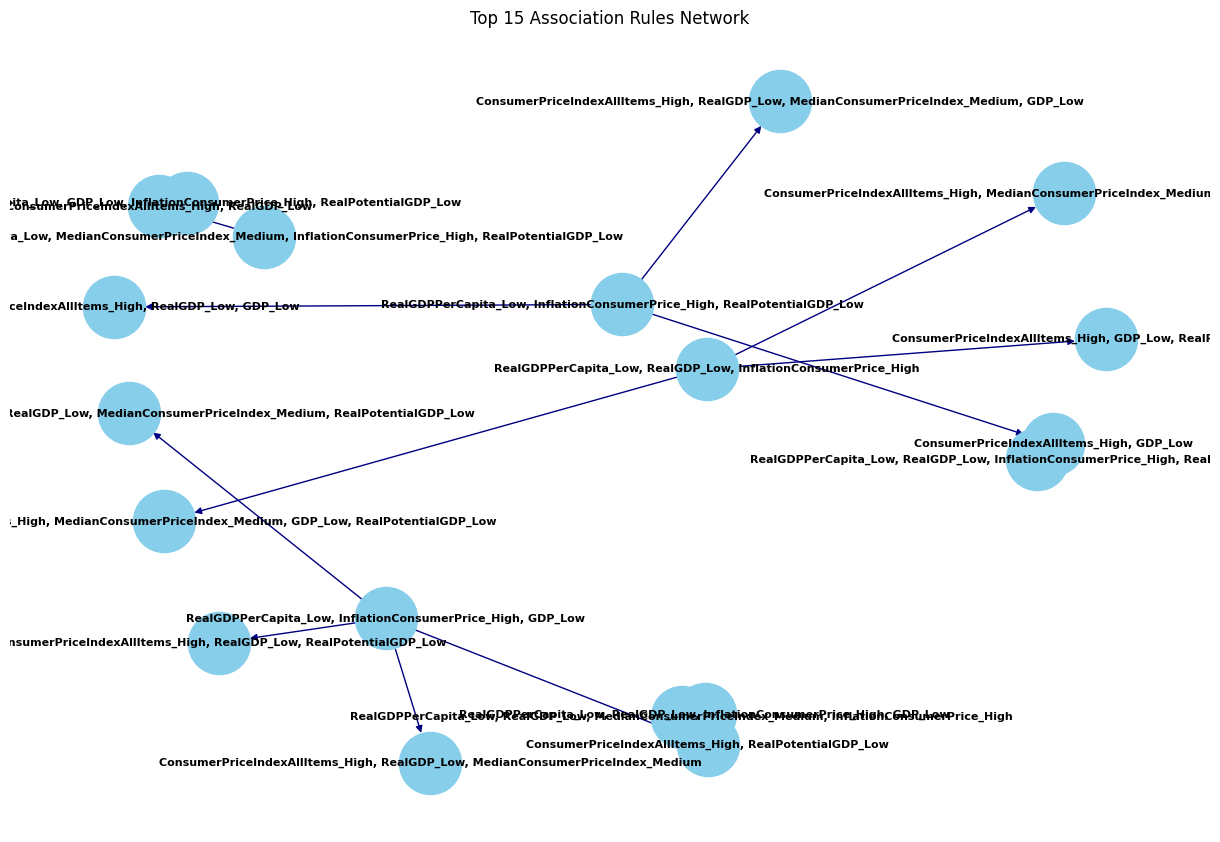

In [47]:
# Apply Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

# Generate rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Create graph
G = nx.DiGraph()

top_rules = rules.sort_values('lift', ascending=False).head(15)

for _, row in top_rules.iterrows():
    lhs = ', '.join(list(row['antecedents']))
    rhs = ', '.join(list(row['consequents']))
    G.add_edge(lhs, rhs, weight=row['lift'], support=row['support'], confidence=row['confidence'])

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=8, font_weight='bold', edge_color='navy')
plt.title("Top 15 Association Rules Network")
plt.show()